<div style="background: white;
            padding: 30px 35px;
            border-radius: 8px;
            border-left: 6px solid #e94560;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;">

<h1 style="margin-bottom: 5px;">NB01: Data Collection — Portfolio Risk Dashboard</h1>

<p style="font-weight: bold; margin-top: 0;">Personal Project · Portfolio Risk & Data Science · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 11th April 2026</li>
    <li>🎯 <strong>Purpose:</strong> Collect real historical price data for a 5-asset portfolio and prepare it for downstream risk modelling</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li>Yahoo Finance via <code>yfinance</code> API</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/raw/prices.csv</code> — cleaned daily adjusted closing prices</li>
    <li><code>../data/processed/returns.csv</code> — daily log returns</li>
    <li><code>../figures/price_history.png</code> — normalised price chart</li>
    <li><code>../figures/return_distributions.png</code> — return distribution plots</li>
    <li><code>../figures/correlation_matrix.png</code> — correlation heatmap</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Adjusted price download with <code>yfinance</code></li>
    <li>Log return computation</li>
    <li>Missing value handling with forward fill</li>
    <li>Normalised price visualisation with crisis shading</li>
    <li>Correlation analysis</li>
</ul>

<p><strong>Workflow:</strong> Download → Clean → Visualise Prices → Compute Returns → Correlation → Save</p>

</div>

## ⚙️ Importing Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📋 Section 1: Configuration & Portfolio Setup

### 📍 Define Portfolio

In [7]:
# Define the 5 assets in the portfolio and their full names
TICKERS = {
    "SPY":  "S&P 500 ETF",
    "TLT":  "20Y US Treasury ETF",
    "GLD":  "Gold ETF",
    "QQQ":  "Nasdaq 100 ETF",
    "EEM":  "Emerging Markets ETF"
}

# Set the date range (10 years of data from 2016 to end of 2025)
START_DATE = "2016-01-01"
END_DATE   = "2025-12-31"

# Define how much of the portfolio each asset gets (must add up to 1.0)
# SPY=35%, TLT=25%, GLD=15%, QQQ=15%, EEM=10%
WEIGHTS    = [0.35, 0.25, 0.15, 0.15, 0.10]

# Print a summary to confirm everything is set correctly
print(f"✅ Portfolio configured")
print(f"📅 Period  : {START_DATE} → {END_DATE}")
print(f"📊 Assets  : {list(TICKERS.keys())}")
print(f"⚖️  Weights : {WEIGHTS} (sum = {sum(WEIGHTS)})")

✅ Portfolio configured
📅 Period  : 2016-01-01 → 2025-12-31
📊 Assets  : ['SPY', 'TLT', 'GLD', 'QQQ', 'EEM']
⚖️  Weights : [0.35, 0.25, 0.15, 0.15, 0.1] (sum = 1.0)


## 📥 Section 2: Download Price Data

### 📍 Pull Adjusted Closing Prices from Yahoo Finance

In [8]:
# Starting the download
print("⏳ Downloading data...")

# Download 10 years of daily price data for all 5 tickets from Yahoo Finance
# auto_adjust=True adjusts prices for stock splits and dividends automatically
# progress=False hides the download progress bar to keep output clean
raw    = yf.download(list(TICKERS.keys()), start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=False)

# Extract only the closing price column - we don't need Open, High, Low, Volume                  
prices = raw["Close"].copy()

# Remove the unnecessary "Ticker" label sitting above the column names
prices.columns.name = None

# Label the row index as "Date" for clarity
prices.index.name   = "Date"

# Confirm download worked and show the shape and date range
print(f"✅ Download complete — Shape: {prices.shape}")
print(f"📅 Range: {prices.index[0].date()} → {prices.index[-1].date()}")

# Preview the first 5 rows
prices.head()

⏳ Downloading data...
✅ Download complete — Shape: (2513, 5)
📅 Range: 2016-01-04 → 2025-12-30


,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2016-01-04,24.951824,102.889999,101.605629,169.471542,90.649757
2016-01-05,25.007608,103.180000,101.429367,169.758179,90.284042
2016-01-06,24.529451,104.669998,100.455032,167.616837,91.500656
2016-01-07,23.772369,106.150002,97.309433,163.595490,91.664825
2016-01-08,23.517351,105.680000,96.511475,161.799713,92.075417


## 🧹 Section 3: Data Cleaning

### 📍 Check & Handle Missing Values

In [9]:
# Count missing values for each asset before cleaning
print("🔍 Missing values per asset:")
print(prices.isnull().sum())

# Forward fill - replaces missing values with the last known price
# This makes sense for market holidays where no trading occurred
# Then drop any remaining rows that are still NaN after forward filling
prices = prices.ffill().dropna()

# Confirm the shape hasn't changed and no nulls remain
print(f"\n✅ After cleaning — Shape: {prices.shape}")
print(f"❌ Remaining nulls: {prices.isnull().sum().sum()}")

🔍 Missing values per asset:
EEM    0
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

✅ After cleaning — Shape: (2513, 5)
❌ Remaining nulls: 0


## 📈 Section 4: Price Visualisation

### 📍 Plot Normalised Price History

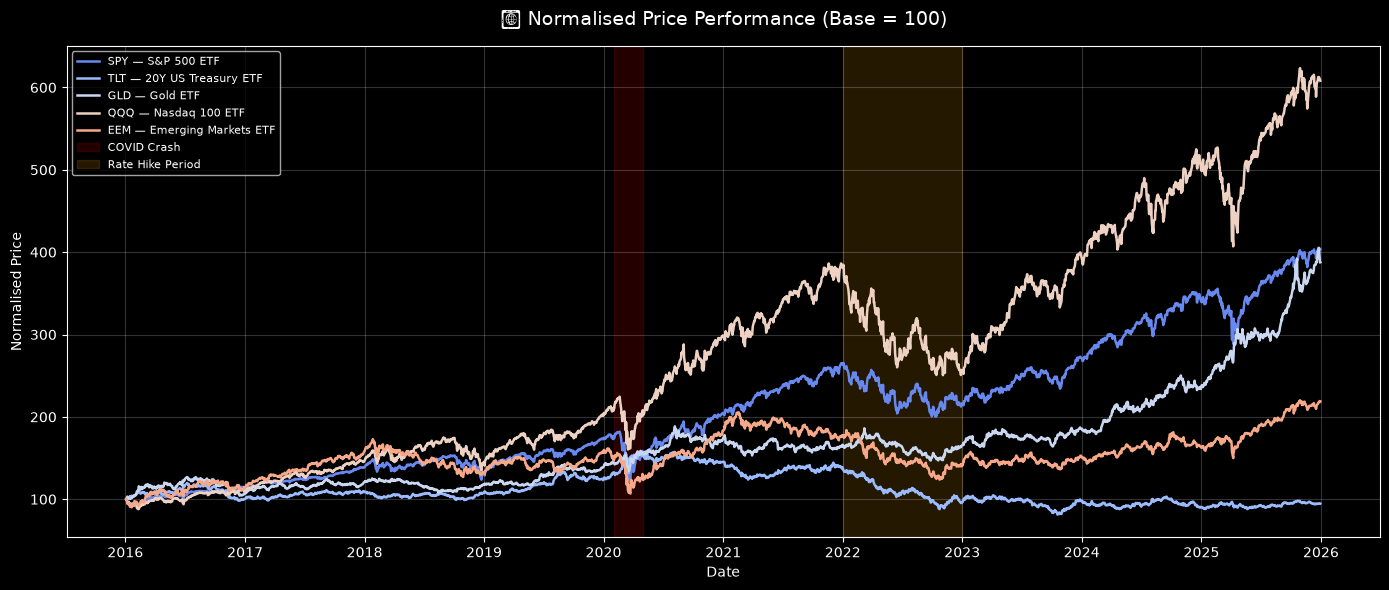

💾 Saved to ../figures/price_history.png


In [10]:
# Nornalise all prices to start at 100 on the first day
# This lets us compare performance across assets regardless of their actual price levels
# e.g., SPY at $170 and EEM at $25 both become 100, so we can compare growth fairly
normalised = (prices / prices.iloc[0]) * 100

# Create a single chart 14 inches wide and 6 inches tall
fig, ax = plt.subplots(figsize=(14, 6))

# Loop through each asset and plot its normalised price line
# TICKERS.items() gives us both the ticker symbol and its full name for the legend
for ticker, label in TICKERS.items():
    ax.plot(normalised.index, normalised[ticker],
            label=f"{ticker} — {label}", linewidth=1.8)

# Shade the COVID crash period (Feb-Apr 2020) in red
# alpha=0.15 makes it semi-transparent so the price lines are still visible
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"),
           alpha=0.15, color="red", label="COVID Crash")

# Shade the 2022 rate hike period in orange
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           alpha=0.15, color="orange", label="Rate Hike Period")

# Add chart labels, title, legend and grid
ax.set_title("📈 Normalised Price Performance (Base = 100)", fontsize=14, pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price")
ax.legend(loc="upper left", fontsize=8)

# Format x-axis to show just the year (e.g., "2020") instead of full timestamps
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.2)

# Save and display the chart
plt.tight_layout()
plt.savefig("../figures/price_history.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/price_history.png")

## 📉 Section 5: Log Returns

### 📍 Step 1: Compute Daily Log Returns

In [11]:
# Compute daily log returns for each asset
# prices.shift(1) shifts all prices down by one row, giving yesterday's price in each row
# prices / prices.shift(1) gives today's price divided by yesterday's price (gross return)
# np.log(...) takes the natural log to convert to log return
# .dropna() removes the first row which has no previous price to calculate a return from
returns = np.log(prices / prices.shift(1)).dropna()

# Confirm shape and show summary statistics for each asset
print(f"✅ Log returns computed — Shape: {returns.shape}")
returns.describe().round(4)

✅ Log returns computed — Shape: (2512, 5)


,EEM,GLD,QQQ,SPY,TLT
count,2512.0000,2512.0000,2512.0000,2512.0000,2512.0000
mean,0.0003,0.0005,0.0007,0.0006,-0.0000
std,0.0129,0.0093,0.0141,0.0114,0.0094
min,-0.1333,-0.0664,-0.1276,-0.1159,-0.0690
25%,-0.0062,-0.0045,-0.0050,-0.0036,-0.0057
50%,0.0009,0.0007,0.0013,0.0007,0.0003
75%,0.0075,0.0055,0.0078,0.0059,0.0054
max,0.0775,0.0479,0.1134,0.0999,0.0725


### 📍 Step 2: Plot Return Distributions

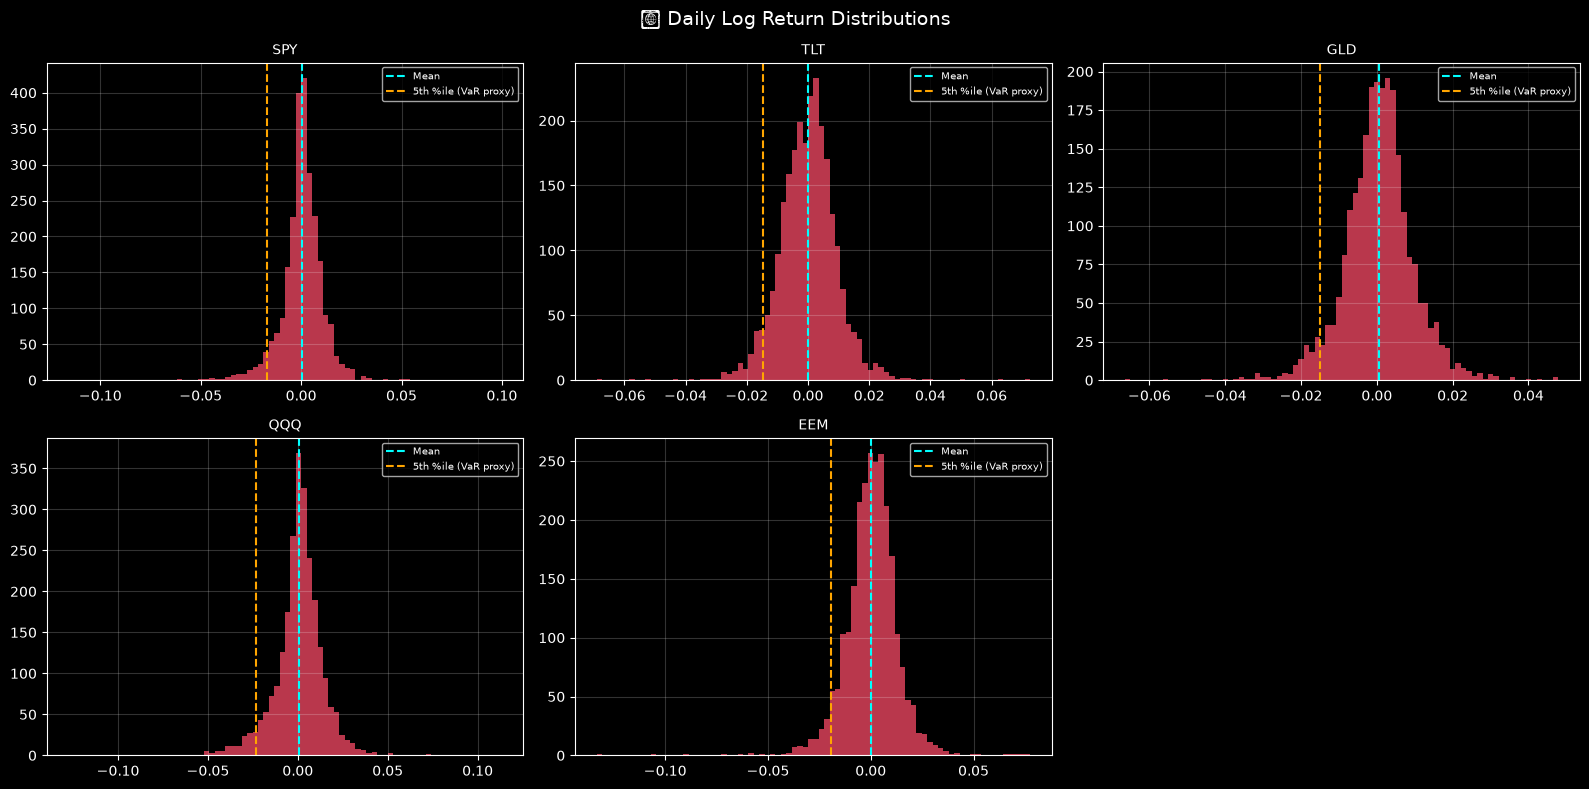

💾 Saved to ../figures/return_distributions.png


In [12]:
# Create a grid of 2 rows x 3 columns to fit 5 asset charts (6th slot left empty)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Flatten the 2D grid into a 1D list so we can loop through with a simple index
axes = axes.flatten()

# Loop through each asset and plot its return distribution
for i, ticker in enumerate(TICKERS.keys()):
    # Plot histogram of daily log returns for this asset
    axes[i].hist(returns[ticker], bins=80, color="#e94560", edgecolor="none", alpha=0.8)

    # Draw a vertical line at the mean return (cyan)
    axes[i].axvline(returns[ticker].mean(), color="cyan", linestyle="--", label="Mean")

    # Draw a vertical line at the 5th percentile - this is the VaR proxy
    # It marks the threshold below which only 5% of days fall
    axes[i].axvline(returns[ticker].quantile(0.05), color="orange",
                    linestyle="--", label="5th %ile (VaR proxy)")

    axes[i].set_title(f"{ticker}", fontsize=10)
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.2)

# Hide the 6th empty subplot since we only have 5 assets
axes[-1].set_visible(False)

# Add overall title, save and display
fig.suptitle("📉 Daily Log Return Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/return_distributions.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/return_distributions.png")

## 🔗 Section 6: Correlation Analysis

### 📍 Correlation Heatmap

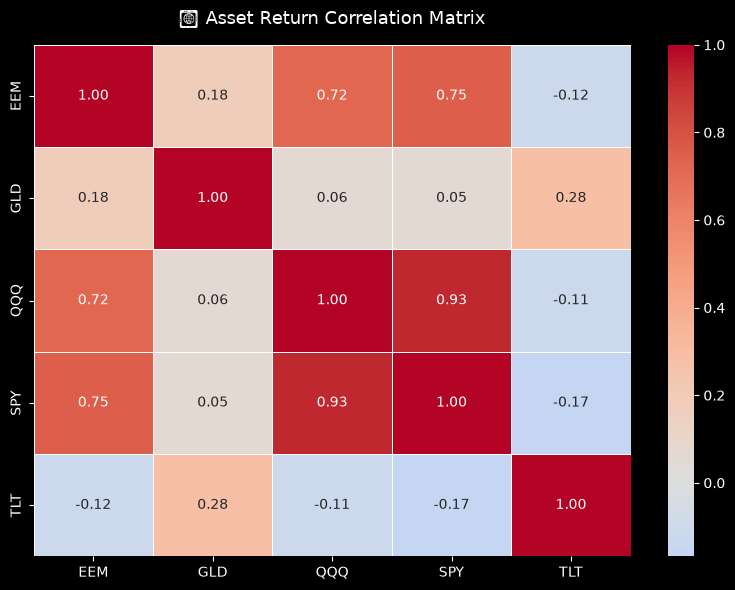


💡 Assets with low/negative correlation reduce portfolio risk through diversification.


In [13]:
# Calculate the correlation matrix - how each asset's daily returns move relative to each other
# Values range from -1 (perfectly opposite) to +1 (perfectly together) to 0 (unrelated)
corr = returns.corr()

# Create the chart
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the heatmap
# annot=True - show the correlation number inside each cell
# fmt=".2f" - round numbers to 2 decimal places
# cmap="coolwarm" - red = positive correlation, blue = negative, white = zero
# center=0 - makes white sit at zero so the colour scale is intuitive
# linewidths=0.5 - adds thin lines between cells for readability
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
            
ax.set_title("🔗 Asset Return Correlation Matrix", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../figures/correlation_matrix.png", dpi=150)
plt.show()

print("\n💡 Assets with low/negative correlation reduce portfolio risk through diversification.")

## 💾 Section 7: Save Data

### 📍 Export to CSV

In [14]:
# Save the raw prices to the raw folder - this is the direct download from Yahoo Finance, unmodified
prices.to_csv("../data/raw/prices.csv")

# Save the computed log returns to the processed folder - derived from prices, so it counts as processed data
returns.to_csv("../data/processed/returns.csv")

print("✅ Files saved:")
print("   📄 ../data/raw/prices.csv")
print("   📄 ../data/processed/returns.csv")
print("\n🚀 Ready for NB02 — Risk Modelling (VaR & Expected Shortfall)")

✅ Files saved:
   📄 ../data/raw/prices.csv
   📄 ../data/processed/returns.csv

🚀 Ready for NB02 — Risk Modelling (VaR & Expected Shortfall)


## 🪞 Personal Reflection Notes — NB01

**🎯 Key Decisions Made in This Notebook**

The first decision was asset selection. I chose five ETFs (SPY, TLT, GLD, QQQ, and EEM) to represent a diversified multi-asset portfolio spanning US equities, bonds, gold, tech, and emerging markets. The intention was to include assets that behave differently under stress, which is a core requirement for meaningful risk analysis. I also chose a 10-year window (2016–2025) deliberately to capture two major stress events: the COVID crash of 2020 and the 2022 rate hike cycle.

The second decision was to use log returns rather than simple returns. Log returns are mathematically additive across time, meaning you can simply sum daily log returns to get the return over any longer period — a convenient property for risk calculations. They are also closer to normally distributed than simple returns, which matters because the parametric VaR model I will build in NB02 assumes returns follow a normal distribution. Think of it like this: a stock that falls 50% needs to rise 100% to recover, not 50% — log returns capture this asymmetry in a mathematically cleaner way than simple returns do.

The third decision was forward-filling missing values rather than dropping them. On reflection, this was the most defensible choice for daily price data: a missing price on a public holiday simply means no trading occurred, so carrying the last known price forward is more accurate
than creating a gap in the series. Dropping the row entirely would imply the asset had no value that day, which is clearly wrong.

**📊 What the Charts Revealed**

The normalised price chart was more informative than I expected. QQQ's outperformance (~6x over 10 years) versus EEM's near-stagnation was stark. QQQ's strong performance reflects the dominance of US mega-cap technology companies — Apple, Nvidia, Microsoft, Meta — whose earnings grew dramatically over this period, pushing their stock prices up and dragging the whole index with them. EEM's stagnation, by contrast, reflects headwinds specific to emerging markets: China's economic slowdown, geopolitical tensions, and the strengthening US dollar, which makes dollar-denominated debt more expensive for emerging market companies to service and reduces the attractiveness of their assets to foreign investors.

TLT's trajectory was the most instructive from a risk perspective. To understand it, you need to know one key relationship: when interest rates rise, existing bond prices fall. This is because a bond pays a fixed coupon — if new bonds are issued at higher rates, your existing bond paying a lower rate becomes less valuable, so its price drops to compensate. TLT holds long-dated 20-year US government bonds, which are especially sensitive to rate changes because you are locked into the fixed coupon for longer. TLT spiked during COVID because the Federal Reserve slashed rates to near zero to stimulate the economy — lower rates made existing bonds more valuable. But then in 2022, the Fed raised rates at the fastest pace in 40 years to fight inflation, and TLT fell all the way back to its 2016 starting level. This reminded me that "safe" assets are only safe in certain regimes.

The return distributions confirmed something important going into NB02: all five assets exhibit fat tails. In a true normal distribution, extreme moves (say, more than 3 standard deviations) should be vanishingly rare — perhaps once in hundreds of years. But financial markets regularly produce these so-called "black swan" events. The intuition is that markets are driven by human behaviour: fear and greed cause herding, and herding causes crashes and bubbles far more extreme than a normal distribution would predict. SPY and QQQ both showed single-day moves of nearly ±10% during the COVID crash of March 2020 — something a normal distribution would assign a near-zero probability to. This means the parametric VaR model will likely underestimate tail risk, and I expect the historical and Monte Carlo methods to give more conservative
estimates as a result.

The correlation matrix confirmed the portfolio's diversification structure, and produced one finding that surprised me. SPY and QQQ are almost perfectly correlated (0.93) because QQQ is dominated by the same mega-cap tech stocks that make up a large share of the S&P 500 — holding both is essentially doubling down on the same bet rather than diversifying. GLD showed near-zero correlation with equities (0.05–0.18), which makes intuitive sense: gold has no earnings, no dividends, and no cash flows — its price is driven almost entirely by investor sentiment and inflation expectations, which move independently of corporate profits. This makes it a genuine diversifier.

TLT's negative correlation with equities (-0.11 to -0.17) reflects the classic "flight to safety" dynamic: when stock markets fall, investors panic and move money into government bonds, pushing bond prices up. This is the relationship that makes a traditional 60/40 stock/bond portfolio work — bonds cushion equity losses. However the correlation was weaker than I expected, and the reason is 2022. That year was unusual because both stocks and bonds fell simultaneously — equities fell because rising rates reduce the present value of future earnings, while bonds fell for the mechanical reason explained above. Because 2022 sits in our 10-year window, it pulled the average correlation toward zero, making TLT look like a weaker diversifier than it historically has been.

EEM's correlation with SPY (0.75) was higher than I anticipated. The intuition here is contagion: in a genuine global crisis, investors sell everything indiscriminately to raise cash, regardless of geography. Emerging markets, which already carry higher perceived risk, tend to get sold off even faster than developed markets in a panic. So the diversification benefit of EEM exists during normal times but tends to disappear precisely when you need it most.

**🔜 What This Sets Up for NB02**

The key tension heading into NB02 is between the normality assumption and the fat tails observed in the data. I expect parametric VaR to understate risk relative to historical and Monte Carlo VaR, and I will use that comparison as the central analytical thread of the next notebook. The weak TLT-equity correlation also means the portfolio has less downside protection than a textbook 60/40 allocation would suggest — which should show up clearly in the portfolio-level VaR calculations.